# Calculus

In [77]:
# ---- Units ----
p = 1e-12
n = 1e-9
u = 1e-6
m = 1e-3
k = 1e3
M = 1e6
G = 1e9
import sympy as sp
import numpy as np
import math

# Examen 1

In [80]:
"""
Newton-Raphson Calculator for RLC Circuit Verification
Author: Orlando Reyes
Date: March 6, 2026

This script solves the same RLC differential equation as the STM32 code.
Finds resistance R such that: exp(-0.5*R*t/L) * cos(omega*t) = q
where omega = sqrt(1/(L*C) - R^2/(4*L^2))
L 10
C 0.0002
t 0.01
q 0.05
Intervalos
"""

def f(R, L, C, t, q):
    """
    RLC circuit function: exp(-0.5*R*t/L) * cos(omega*t) - q
    
    Parameters:
    R: Resistance (variable to solve for)
    L: Inductance (Henry)
    C: Capacitance (Farad)
    t: Time (seconds)
    q: Target charge/voltage
    
    Returns:
    Function value
    """
    omega = math.sqrt(1.0/(L*C) - (R*R)/(4.0*L*L))
    expo = math.exp((-0.5*R*t)/L)
    return expo * math.cos(omega*t) - q


def df(R, L, C, t):
    """
    Derivative of f with respect to R
    
    Returns:
    df/dR
    """
    omega = math.sqrt(1.0/(L*C) - (R*R)/(4.0*L*L))
    expo = math.exp((-0.5*R*t)/L)
    
    # df/dR = expo * [-(t/(2L))*cos(omega*t) + (R*t/(4*L^2*omega))*sin(omega*t)]
    result = expo * (
        -(t/(2.0*L))*math.cos(omega*t) +
        (R*t/(4.0*L*L*omega))*math.sin(omega*t)
    )
    return result


def newton_raphson(L, C, t, q, x0=0.5, max_iter=50, precision=0.0001):
    """
    Newton-Raphson method to find R
    
    Parameters:
    L: Inductance (H)
    C: Capacitance (F)
    t: Time (s)
    q: Target value
    x0: Initial guess for R
    max_iter: Maximum iterations
    precision: Convergence tolerance
    
    Returns:
    result: Dictionary with solution details
    """
    x_prev = x0
    iteration = 0
    
    print("=" * 80)
    print("NEWTON-RAPHSON METHOD - RLC CIRCUIT")
    print("=" * 80)
    print(f"\nCircuit Parameters:")
    print(f"  L (Inductance) = {L} H")
    print(f"  C (Capacitance) = {C} F")
    print(f"  t (Time) = {t} s")
    print(f"  q (Target value) = {q}")
    print(f"\nNumerical Parameters:")
    print(f"  Initial guess (x0) = {x0}")
    print(f"  Max iterations = {max_iter}")
    print(f"  Precision = {precision}")
    
    print("\n" + "-" * 80)
    print(f"{'Iter':<6} {'R':<15} {'f(R)':<15} {'f\'(R)':<15} {'Error (%)':<15}")
    print("-" * 80)
    
    while iteration < max_iter:
        fx = f(x_prev, L, C, t, q)
        dfx = df(x_prev, L, C, t)
        
        # Check for zero derivative
        if abs(dfx) < 1e-10:
            print(f"\n⚠ Warning: Derivative too small at iteration {iteration}")
            return {
                'value': x_prev,
                'error': None,
                'iterations': iteration,
                'success': False,
                'message': 'Zero derivative encountered'
            }
        
        # Newton-Raphson formula
        x_next = x_prev - fx / dfx
        
        # Calculate relative error
        if abs(x_next) > 1e-10:
            error = abs((x_next - x_prev) / x_next) * 100
        else:
            error = abs(x_next - x_prev) * 100
        
        print(f"{iteration:<6} {x_prev:<15.6f} {fx:<15.6e} {dfx:<15.6e} {error:<15.6f}")
        
        # Check convergence
        if abs(fx) < precision:
            print("-" * 80)
            print(f"\n✓ Converged after {iteration} iterations!")
            print(f"  R = {x_prev:.6f} Ω")
            print(f"  f(R) = {fx:.6e}")
            print(f"  Error = {error:.6f}%")
            
            return {
                'value': x_prev,
                'error': error,
                'iterations': iteration,
                'success': True,
                'message': 'Converged successfully'
            }
        
        x_prev = x_next
        iteration += 1
    
    # Max iterations reached
    print("-" * 80)
    print(f"\n⚠ Maximum iterations ({max_iter}) reached without convergence")
    print(f"  Best R = {x_prev:.6f} Ω")
    print(f"  f(R) = {f(x_prev, L, C, t, q):.6e}")
    
    return {
        'value': x_prev,
        'error': None,
        'iterations': iteration,
        'success': False,
        'message': 'Max iterations reached'
    }


def verify_solution(R, L, C, t, q):
    """
    Verify the solution by checking if f(R) ≈ 0
    """
    result = f(R, L, C, t, q)
    
    print("\n" + "=" * 80)
    print("VERIFICATION:")
    print("=" * 80)
    print(f"f({R:.6f}) = {result:.6e}")
    
    omega = math.sqrt(1.0/(L*C) - (R*R)/(4.0*L*L))
    damping_factor = math.exp((-0.5*R*t)/L)
    oscillation = math.cos(omega*t)
    
    print(f"\nBreakdown:")
    print(f"  ω (angular frequency) = {omega:.6f} rad/s")
    print(f"  Damping factor e^(-Rt/2L) = {damping_factor:.6f}")
    print(f"  Oscillation cos(ωt) = {oscillation:.6f}")
    print(f"  Product = {damping_factor * oscillation:.6f}")
    print(f"  Target q = {q:.6f}")
    print(f"  Difference = {abs(damping_factor * oscillation - q):.6e}")
    
    if abs(result) < 1e-4:
        print("\n✓ Solution verified!")
    else:
        print("\n⚠ Solution may need more iterations")



In [82]:
L = 0.1
C = 0.001
t = 0.05
q = 0.8
x0 = 0.5
max_it = 50
precision = 0.001

# Solve using Newton-Raphson
result = newton_raphson(L, C, t, q, x0, max_it, precision)
print(result)


NEWTON-RAPHSON METHOD - RLC CIRCUIT

Circuit Parameters:
  L (Inductance) = 0.1 H
  C (Capacitance) = 0.001 F
  t (Time) = 0.05 s
  q (Target value) = 0.8

Numerical Parameters:
  Initial guess (x0) = 0.5
  Max iterations = 50
  Precision = 0.001

--------------------------------------------------------------------------------
Iter   R               f(R)            f'(R)           Error (%)      
--------------------------------------------------------------------------------
0      0.500000        -5.509918e-01   -6.754520e-02   106.529649     
1      -7.657379       -1.432400e+00   8.577876e-01    27.889375      
2      -5.987502       -5.397314e-01   2.847912e-01    46.310733      
3      -4.092319       -2.969972e-01   1.722624e-02    131.123466     
4      13.148661       -8.302760e-01   2.794633e-03    95.761850      


ValueError: math domain error

# Examen 2

In [70]:
'''
'''

L = 1e-3
C = 100e-6
wn = 1.0 / np.sqrt(L * C)
z = 0.57
sqrt = sp.sqrt(1-z**2)
t = 0.0002
# wn = sp.Symbol('wn')
# z = sp.Symbol('z')
# sqrt = sp.Symbol('sqrt')
s = sp.Symbol('s')
# t = sp.Symbol('t')



In [71]:
fs = wn**2/(s**2 + 2*wn*z*s + wn**2)
#t = 15e-4
laplace_ft = sp.inverse_laplace_transform(fs, s, t)
ft = wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t) # rads
print(f"wn = {wn}, a = {sp.E**(-z*wn*t)}, b = {sp.sin(wn*sqrt*t)}, ft_con = {ft/sqrt}")
#print(f"ft_con = {ft/sqrt}")
laplace_ft

wn = 3162.277660168379, a = 0.697327816894970, b = 0.496579609062921, ft_con = 1332.72890825676


1332.72890825676

In [72]:
# start from t =0.0001 to 20 samples
for i in range(0,20):
    t = 0.1 * m * i
    ft = wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t)/sqrt # rads:
    print(ft)

0
825.697395068441
1332.72890825676
1575.32874601239
1613.33336985008
1505.50367131882
1304.95789430105
1056.45670987395
795.205902164342
546.817018831797
328.078778866606
148.229614095758
10.4737092217852
-86.4593902590118
-146.854647068292
-176.742344439501
-182.867725167179
-171.912962397835
-149.959869603950
-122.165221200810


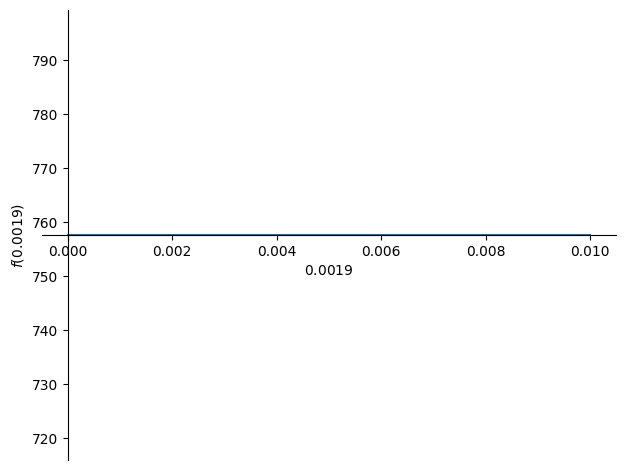

In [69]:
plot = sp.plot(laplace_ft, (t, 0, 0.01), show=False);plot.show()

In [122]:
for i in range(0, 11) :
    t = i*0.001
    print(f"f({t}) = {wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t)}" )


f(0.0) = 0
f(0.001) = 603.042455577324
f(0.002) = -88.7809849940113
f(0.003) = -34.0576372693854
f(0.004) = 11.9523136475549
f(0.005) = 0.901984005484630
f(0.006) = -1.06687222259932
f(0.007) = 0.0865762351262609
f(0.008) = 0.0706308008861705
f(0.009000000000000001) = -0.0171643774386986
f(0.01) = -0.00299286950989524


f(0.0) = 0
f(0.001) = 603.042455577324
f(0.002) = -88.7809849940113
f(0.003) = -34.0576372693854
f(0.004) = 11.9523136475549
f(0.005) = 0.901984005484630
f(0.006) = -1.06687222259932
f(0.007) = 0.0865762351262609
f(0.008) = 0.0706308008861705
f(0.009000000000000001) = -0.0171643774386986
f(0.01) = -0.00299286950989524


1.00000000000000

In [36]:

# Newton Interpolation with the 20 sample points
import numpy as np

# The 20 sample values from H(t)
y_samples = np.array([441.495, 762.995, 977.341, 1099.257, 1144.266, 1127.811, 
                      1064.581, 968.0268, 850.037, 720.764, 588.554,
                      455.991, 340.025, 232.058, 138.208, 59.473, 
            -4.0522, -52.975, -88.42])

# Time samples: t = 0.1*m*i for i=0 to 18 (19 points)
m_val = 1e-3
x_samples = np.array([0.1 * m_val * i for i in range(len(y_samples))])

print(f"Number of samples: {len(x_samples)}")
print(f"Time range: {x_samples[0]} to {x_samples[-1]} seconds")
print(f"X-samples (times in seconds):")
print(x_samples)
print()

# Newton Divided Differences
def divided_differences(x, y):
    n = len(x)
    a = y.copy().astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            a[i] = (a[i] - a[i-1]) / (x[i] - x[i-j])
    return a

# Horner's nested evaluation
def newton_eval(x_eval, x_nodes, a):
    result = a[-1]
    for i in range(len(a)-2, -1, -1):
        result = result * (x_eval - x_nodes[i]) + a[i]
    return result

# Compute coefficients
a = divided_differences(x_samples, y_samples)

print("Newton Divided Differences Coefficients a[]:")
for i, coef in enumerate(a):
    print(f"  a[{i}] = {coef:.6e}")
print()

# Test evaluation at some points
print("=" * 70)
print("NEWTON INTERPOLATION RESULTS")
print("=" * 70)

test_points = float(input("Enter a time value to evaluate P(t) (e.g., 0.0018): "))

p_val = newton_eval(test_points, x_samples, a)
print(f"P({test_points:.4f}) = {p_val:.6f}")


Number of samples: 19
Time range: 0.0 to 0.0018000000000000002 seconds
X-samples (times in seconds):
[0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018]

Newton Divided Differences Coefficients a[]:
  a[0] = 4.414950e+02
  a[1] = 3.215000e+06
  a[2] = -5.357700e+09
  a[3] = 2.454000e+12
  a[4] = 3.329167e+14
  a[5] = -7.325000e+17
  a[6] = 2.847222e+20
  a[7] = -3.015873e+22
  a[8] = -3.571429e+25
  a[9] = 9.314374e+28
  a[10] = -2.452601e+32
  a[11] = -9.429614e+36
  a[12] = 9.901721e+40
  a[13] = -4.992246e+44
  a[14] = 1.668467e+48
  a[15] = -4.175885e+51
  a[16] = 8.356647e+54
  a[17] = -1.393249e+58
  a[18] = 1.990788e+61

NEWTON INTERPOLATION RESULTS
P(0.0020) = 5382143.958000


# Examen 3

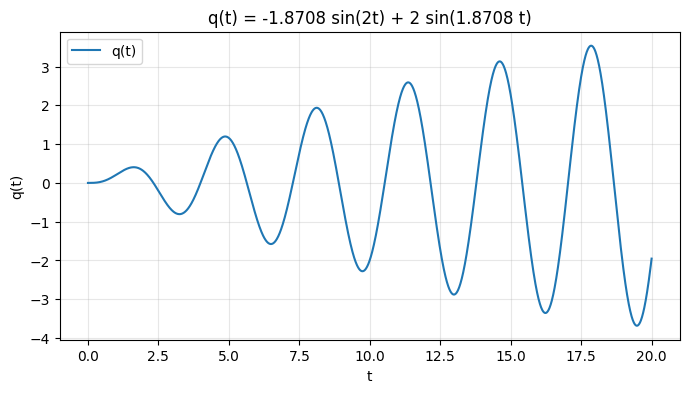

In [2]:
# Analytic solution plot: q(t) = -1.8708 sin(2t) + 2 sin(1.8708 t)
import numpy as np
import matplotlib.pyplot as plt

t_end = 20.0
t = np.linspace(0.0, t_end, 2000)
q = -1.8708 * np.sin(2.0 * t) + 2.0 * np.sin(1.8708 * t)

plt.figure(figsize=(8, 4))
plt.plot(t, q, label="q(t)")
plt.title("q(t) = -1.8708 sin(2t) + 2 sin(1.8708 t)")
plt.xlabel("t")
plt.ylabel("q(t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Numerical integration: trapezoid vs Ralston (RK2)
#
We want to compare the microcontroller results for:
$$
\frac{2}{T}\int_0^{T/2} i(t)^2\,dt
$$
We compute the integral with the trapezoid method and with Ralston (RK2) on the ODE $y'(t)=i(t)^2$, $y(0)=0$.

In [6]:
import numpy as np

def i_t(t, omega, phase, i_max):
    return i_max * np.sin(omega * t + phase)

def integrand_i2(t, omega, phase, i_max):
    i = i_t(t, omega, phase, i_max)
    return i * i

def trap_integral(a, b, n, omega, phase, i_max, verbose=True):
    h = (b - a) / n
    fa = integrand_i2(a, omega, phase, i_max)
    fb = integrand_i2(b, omega, phase, i_max)
    print(f"Trapezoid endpoints: f(a)={fa:.6e}, f(b)={fb:.6e}")
    acc = 0.0
    if verbose:
        print("Trapezoid iterations")
        print("step\tt\tf(t)=i^2(t)\tpartial_sum")
    for k in range(1, n):
        t = a + k * h
        f = integrand_i2(t, omega, phase, i_max)
        acc += f
        if verbose:
            print(f"{k}\t{t:.6e}\t{f:.6e}\t{acc:.6e}")
    I = (h / 2.0) * (fa + 2.0 * acc + fb)
    return I

def ralston_integral(a, b, n, omega, phase, i_max, verbose=True):
    h = (b - a) / n
    t = a
    y = 0.0
    if verbose:
        print("Ralston (RK2) iterations")
        print("step\tt\tk1\tk2\ty_next")
    for k in range(n):
        k1 = integrand_i2(t, omega, phase, i_max)
        k2 = integrand_i2(t + 2.0 * h / 3.0, omega, phase, i_max)
        y_next = y + h * (0.25 * k1 + 0.75 * k2)
        if verbose:
            print(f"{k}\t{t:.6e}\t{k1:.6e}\t{k2:.6e}\t{y_next:.6e}")
        y = y_next
        t += h
    return y

# Match these to your microcontroller settings
omega = 300.0
phase = 45.0
i_max = 4.0
n = 16 # number of subintervals/steps
T = (2.0 * np.pi) / omega
a = 0.0
b = T * 0.5
T

0.020943951023931952

In [11]:

I_trap = trap_integral(a, b, n, omega, phase, i_max, verbose=True)
I_ralston = ralston_integral(a, b, n, omega, phase, i_max, verbose=True)
scaled_trap = ((2.0 / T) * I_trap)**(1/2)
scaled_ralston = (2.0 / T) * I_ralston

print("\nResults")
print(f"Integral (trapezoid) = {I_trap:.9e}")
print(f"Integral (ralston)   = {I_ralston:.9e}")
print(f"Scaled 2/T * I_trap  = {scaled_trap:.9e}")
print(f"Scaled 2/T * I_ralston = {scaled_ralston:.9e}")

Trapezoid endpoints: f(a)=1.158459e+01, f(b)=1.158459e+01
Trapezoid iterations
step	t	f(t)=i^2(t)	partial_sum
1	6.544985e-04	1.404867e+01	1.404867e+01
2	1.308997e-03	1.559190e+01	2.964057e+01
3	1.963495e-03	1.597932e+01	4.561989e+01
4	2.617994e-03	1.515197e+01	6.077186e+01
5	3.272492e-03	1.323580e+01	7.400766e+01
6	3.926991e-03	1.052252e+01	8.453018e+01
7	4.581489e-03	7.425213e+00	9.195540e+01
8	5.235988e-03	4.415411e+00	9.637081e+01
9	5.890486e-03	1.951330e+00	9.832214e+01
10	6.544985e-03	4.081040e-01	9.873024e+01
11	7.199483e-03	2.067545e-02	9.875092e+01
12	7.853982e-03	8.480267e-01	9.959895e+01
13	8.508480e-03	2.764201e+00	1.023631e+02
14	9.162979e-03	5.477478e+00	1.078406e+02
15	9.817477e-03	8.574787e+00	1.164154e+02
Ralston (RK2) iterations
step	t	k1	k2	y_next
0	0.000000e+00	1.158459e+01	1.331351e+01	8.430780e-03
1	6.544985e-04	1.404867e+01	1.519769e+01	1.818964e-02
2	1.308997e-03	1.559190e+01	1.598609e+01	2.858801e-02
3	1.963495e-03	1.597932e+01	1.555867e+01	3.883996e-02
4	2.6179